Model Loaded Successfully
Columns: Index(['Index Name', 'Date', 'Open', 'High', 'Low', 'Close'], dtype='object')
  Index Name        Date      Open      High       Low     Close
0   NIFTY 50  11-10-2024   24985.3  25028.65  24920.05  24964.25
1   NIFTY 50  10-10-2024  25067.05  25134.05   24979.4  24998.45
2   NIFTY 50  09-10-2024   25065.8  25234.05   24947.7  24981.95
3   NIFTY 50  08-10-2024   24832.2     25044   24756.8  25013.15
4   NIFTY 50  07-10-2024   25084.1     25143  24694.35  24795.75


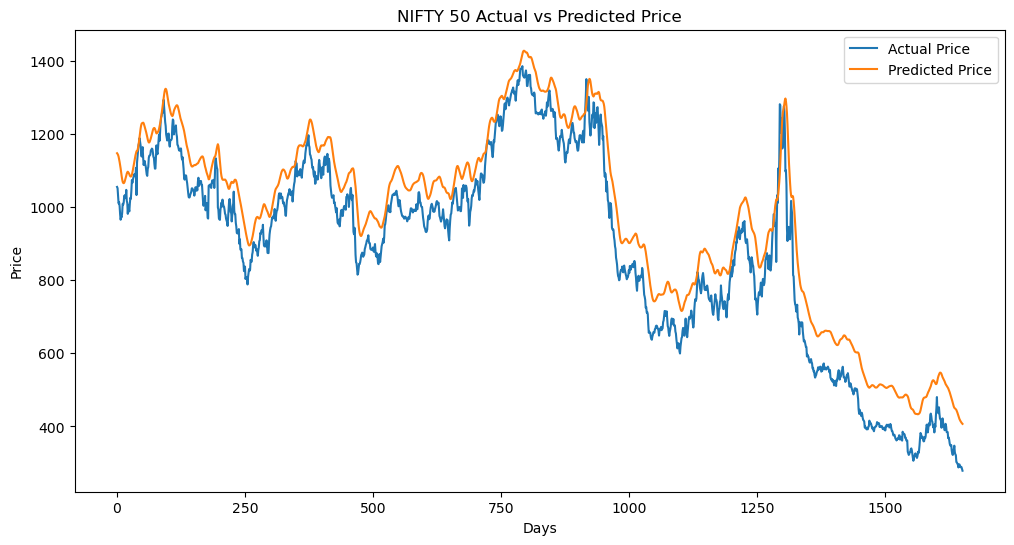

Predicted Next Day NIFTY Price: 405.17288


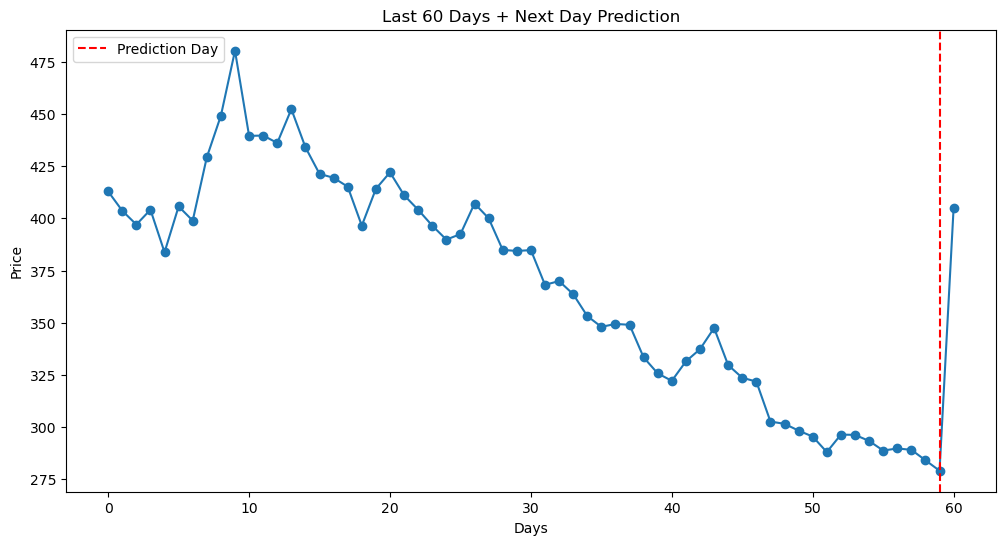

In [1]:
# ===============================
# Notebook 3: Future Prediction
# ===============================

# 1️⃣ Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

# 2️⃣ Load trained model
model = load_model("stock_model.keras", compile=False)
print("Model Loaded Successfully")

# 3️⃣ Load dataset
df = pd.read_csv("NIFTY 50.csv")

print("Columns:", df.columns)
print(df.head())

# 4️⃣ Extract closing prices
data = df[['Close']].values

# 5️⃣ Scale data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# 6️⃣ Create sequences (same as training)
sequence_length = 60
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

# 7️⃣ Split test data (last 20%)
split = int(len(X)*0.8)
X_test = X[split:]
y_test = y[split:]

# 8️⃣ Predict on test set
predictions = model.predict(X_test, verbose=0)

# Convert back to original prices
predictions_real = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test)

# 9️⃣ Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(y_test_real, label="Actual Price")
plt.plot(predictions_real, label="Predicted Price")
plt.title("NIFTY 50 Actual vs Predicted Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

# 🔟 Predict next day price
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1,60,1)

future_price = model.predict(last_60_days, verbose=0)
future_price_real = scaler.inverse_transform(future_price)

print("Predicted Next Day NIFTY Price:", future_price_real[0][0])

# 1️⃣1️⃣ Plot last 60 days + prediction
last_60_real = scaler.inverse_transform(last_60_days.reshape(-1,1))

combined = np.append(last_60_real, future_price_real[0][0])

plt.figure(figsize=(12,6))
plt.plot(combined, marker='o')
plt.axvline(x=59, color='red', linestyle='--', label="Prediction Day")
plt.title("Last 60 Days + Next Day Prediction")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

In [2]:
import pandas as pd

pred_df = pd.DataFrame({
    "Actual_Price": y_test_real.flatten(),
    "Predicted_Price": predictions_real.flatten()
})

pred_df.to_csv("stock_predictions.csv", index=False)

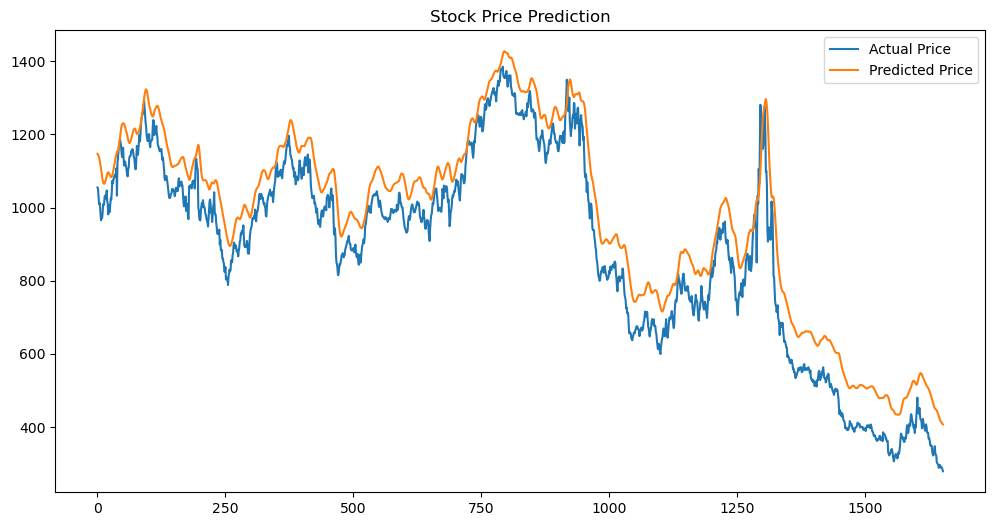

In [3]:
plt.figure(figsize=(12,6))
plt.plot(y_test_real, label="Actual Price")
plt.plot(predictions_real, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction")

plt.savefig("stock_prediction_graph.png")
plt.show()

In [4]:
future_df = pd.DataFrame({
    "Predicted_Next_Day_Price":[future_price_real[0][0]]
})

future_df.to_csv("next_day_prediction.csv", index=False)

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
mae = mean_absolute_error(y_test_real, predictions_real)

print("Model Evaluation Metrics")
print("RMSE:", rmse)
print("MAE:", mae)

Model Evaluation Metrics
RMSE: 93.60322091682251
MAE: 85.66677804751895
